In [166]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [167]:
file = pd.read_csv("Fish.csv") ## pd.read_excel("file1.xlsx")
X = file.iloc[:,2:].values
X = np.c_[X, X**2]
Y = file.iloc[:,1].values ## I.M.P ... " :1 -- Creates a 2-D ARRAY .. it's waste for us .. "

In [168]:
np.random.seed(42)
indicies = np.random.permutation(len(X))

In [169]:
X = X[indicies]
Y = Y[indicies]
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X = (X - X_mean) / X_std

In [170]:
X_train = X[:100]
Y_train = Y[:100]
# ----
X_val = X[100:130]
Y_val = Y[100:130]
#-----------
X_test = X[130:159]
Y_test = Y[130:159]
# Y_train = Y_train.ravel()

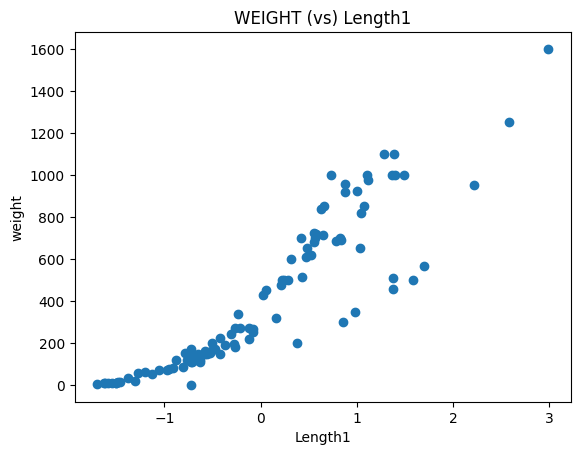

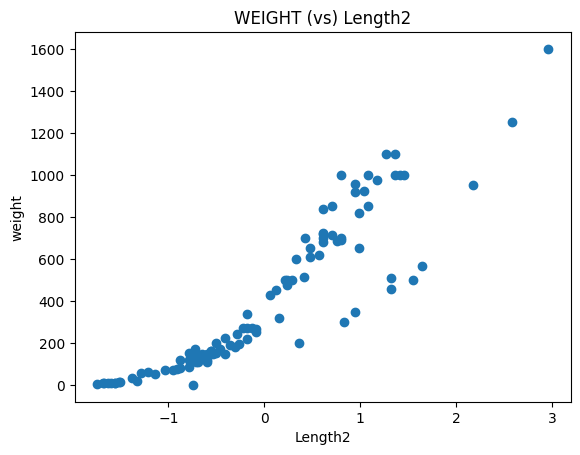

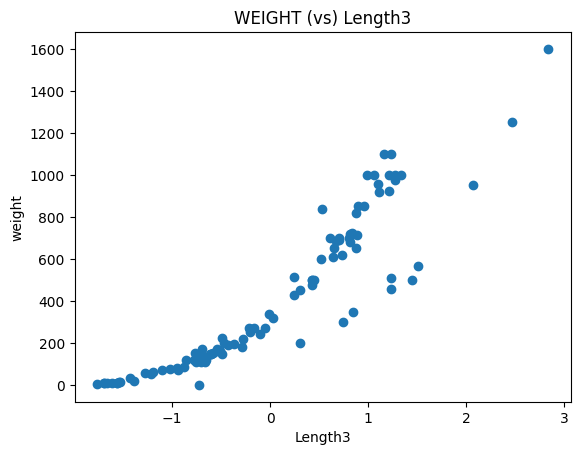

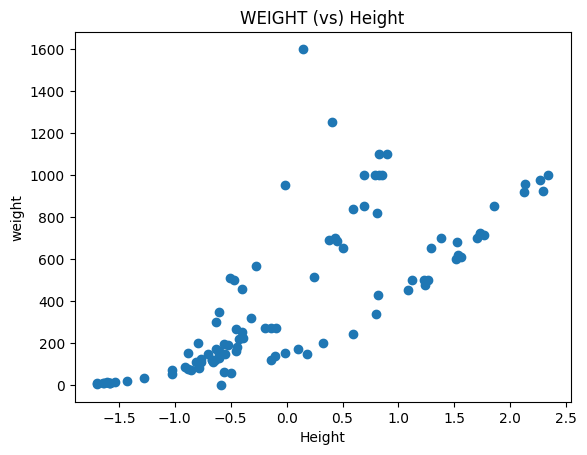

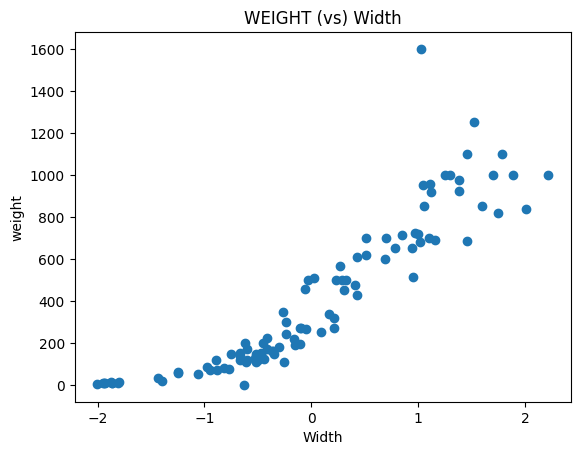

In [171]:
# 1- ANS :: PLooting graphs .. Extracting column names from data_set
feature_names = file.columns[2:]
for i in range(5) :
  plt.scatter(X_train[:,i],Y_train)
  plt.xlabel(feature_names[i])
  plt.ylabel("weight")
  plt.title(f"WEIGHT (vs) {feature_names[i]}")
  plt.show()

In [172]:
X_train = np.c_[np.ones((X_train.shape[0],1)),X_train]
X_val = np.c_[np.ones((X_val.shape[0],1)),X_val]
X_test = np.c_[np.ones((X_test.shape[0],1)),X_test]


In [173]:
Y_train = Y_train.reshape(-1,1)
Y_val = Y_val.reshape(-1,1)
Y_test = Y_test.reshape(-1,1)

In [174]:
def compute_cost(X,Y,teta) :
  m = Y.shape[0]
  Y_pred = np.dot(X,teta) # X.dot(teta) - Also can be used ..
  # cost = ( (1/2) * m)*np.sum( ( Y_pred-Y) **2 ) # MSE
  cost = (1 / (2 * m)) * np.sum((Y_pred - Y) ** 2)
  return cost

In [175]:
def gradient_descent(X,Y,teta,learning_rate,iterations) :
  m = X.shape[0]
  cost_list = []
  for i in range(iterations):
    Y_pred = X.dot(teta)
    d_teta = (1/m) * (np.dot( X.T , Y_pred - Y ) )
    # cost_list.append(compute_cost(X,Y,teta))
    cost = compute_cost(X, Y, teta)
    cost_list.append(cost)
    if i > 1 and abs(cost_list[-2] - cost_list[-1]) < 1e-6:
        break
    teta = teta - (learning_rate) * (d_teta)
  return teta,cost_list

In [176]:
learning_rate = float(input("Enter the Learning-Rate Value :: "))
m = X_train.shape[1]
teta_init = np.zeros((m,1))
iterations = 1000
teta,cost_list = gradient_descent(X_train,Y_train,teta_init,learning_rate,iterations)

Enter the Learning-Rate Value :: 0.05


In [177]:
#2 TRAIN-ERROR (VS) TEST-ERROR ..
train_mse = compute_cost(X_train,Y_train,teta)
test_mse = compute_cost(X_test,Y_test,teta)
print(f"Avg. MSE for train-set is - {train_mse}")
print(f"Avg. MSE for test-set is - {test_mse}")
print(f"OPTIMAL-Param . Theta values are :: {teta}")

Avg. MSE for train-set is - 1480.4094130322617
Avg. MSE for test-set is - 481.40734113321327
OPTIMAL-Param . Theta values are :: [[397.19672038]
 [-63.66701831]
 [-67.86773944]
 [-86.84808269]
 [  4.48564822]
 [-15.11823758]
 [134.50804176]
 [134.28897741]
 [112.47504797]
 [ 87.56982023]
 [163.19069058]]


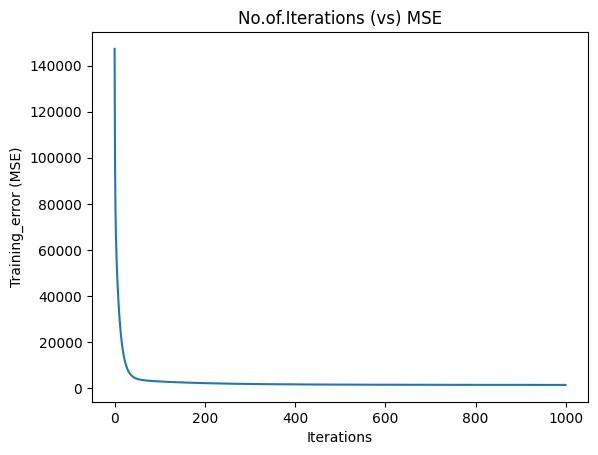

In [178]:
# 3  - M.S.E  (VS) ITERATIONS ..
plt.plot(cost_list)
plt.xlabel("Iterations")
plt.ylabel("Training_error (MSE)")
plt.title("No.of.Iterations (vs) MSE")
plt.show()

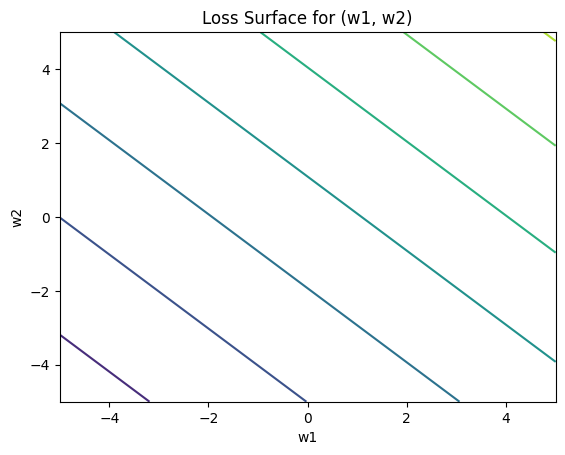

In [179]:
w1_vals = np.linspace(-5, 5, 100)
w2_vals = np.linspace(-5, 5, 100)

loss_surface = np.zeros((len(w1_vals), len(w2_vals)))

for i, w1 in enumerate(w1_vals):
    for j, w2 in enumerate(w2_vals):
        temp_theta = teta.copy()
        temp_theta[1] = w1   # w1 for X1
        temp_theta[2] = w2   # w2 for X2

        loss_surface[i, j] = compute_cost(
            X_train, Y_train, temp_theta
        )

# Contour plot
plt.contour(w1_vals, w2_vals, loss_surface)
plt.xlabel("w1")
plt.ylabel("w2")
plt.title("Loss Surface for (w1, w2)")
plt.show()

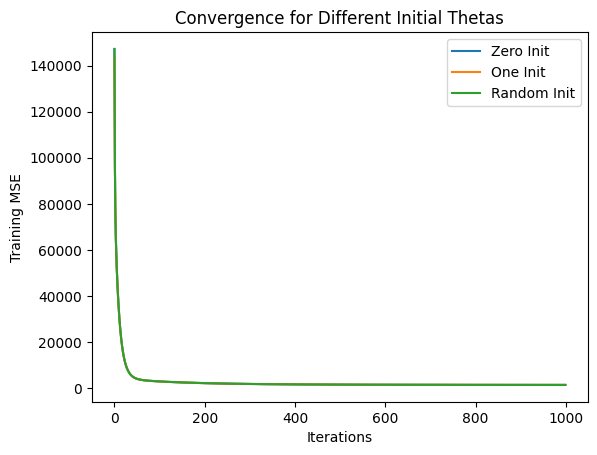

In [180]:
initial_thetas = {
    "Zero Init": np.zeros((X_train.shape[1], 1)),
    "One Init":  np.ones((X_train.shape[1], 1)),
    "Random Init": np.random.randn(X_train.shape[1], 1)
}

results = {}

for name, t0 in initial_thetas.items():
    t_final, cost_hist = gradient_descent(
        X_train, Y_train, t0, learning_rate, iterations
    )

    results[name] = {
        "theta": t_final,
        "final_cost": cost_hist[-1] # it is the final-cost after we get optimal teta-parameter's..
    }

    plt.plot(cost_hist, label=name)

plt.xlabel("Iterations")
plt.ylabel("Training MSE")
plt.title("Convergence for Different Initial Thetas")
plt.legend()
plt.show()

In [181]:
print("\nComparison of final results:")
for name, res in results.items():
    print(name)
    print("Final MSE:", res["final_cost"])
    print("Final theta:\n", res["theta"])
    print("-" * 30)


Comparison of final results:
Zero Init
Final MSE: 1480.5108178378496
Final theta:
 [[397.19672038]
 [-63.66701831]
 [-67.86773944]
 [-86.84808269]
 [  4.48564822]
 [-15.11823758]
 [134.50804176]
 [134.28897741]
 [112.47504797]
 [ 87.56982023]
 [163.19069058]]
------------------------------
One Init
Final MSE: 1480.4634006800022
Final theta:
 [[397.19651791]
 [-63.66293418]
 [-67.87288093]
 [-86.87619684]
 [  4.49549025]
 [-15.10318362]
 [134.53774009]
 [134.30425106]
 [112.4528163 ]
 [ 87.57012786]
 [163.17589644]]
------------------------------
Random Init
Final MSE: 1480.2964910847231
Final theta:
 [[397.20404914]
 [-64.05366704]
 [-67.29848554]
 [-87.58786469]
 [  4.05418133]
 [-14.24538097]
 [134.26936929]
 [133.88863467]
 [113.54893623]
 [ 87.8309484 ]
 [162.59711487]]
------------------------------


In [182]:
# Finding the Optimal-paramters USING HPER-PARAMTER TUNING ...
learn_rates = [0.05,0.08,0.09,0.04]
best_learning_rate_val= None
best_min_error = float("inf")
for lr in learn_rates :
  temp_teta,_ = gradient_descent(X_train,Y_train,teta_init,lr,iterations)
  val_error = compute_cost(X_val,Y_val,temp_teta)
  print(f"FOR This Learning-Rate - {lr} ; the M.S.E was {val_error}")
  if val_error < best_min_error :
    best_min_error = val_error
    best_learning_rate_val = lr

print(f"Finally the best learning-rate which gives min-error was :: {best_learning_rate_val}")



FOR This Learning-Rate - 0.05 ; the M.S.E was 1855.4987085592443
FOR This Learning-Rate - 0.08 ; the M.S.E was 1861.0464128623971
FOR This Learning-Rate - 0.09 ; the M.S.E was 1866.1511799078266
FOR This Learning-Rate - 0.04 ; the M.S.E was 1869.3906670030765
Finally the best learning-rate which gives min-error was :: 0.05


In [183]:
 ### before hyper-tuning .. and after Hyper-tuning M.S.E WAS TEST-SET WAS ..
alpha = 0.00065
before_teta,_ = gradient_descent(X_train,Y_train,teta_init,alpha,iterations)
test_mse_init = compute_cost(X_test,Y_test,before_teta)
best_teta,_= gradient_descent(X_train,Y_train,teta_init,best_learning_rate_val,iterations)
test_mse_tuned = compute_cost(X_test,Y_test,best_teta)
print(f"Before Hyper-parameter Tuning with alpha = {alpha} :: M.S.E WAS - {test_mse_init}")
print(f"After Hyper-parameter Tuning with alpha = {best_learning_rate_val} :: M.S.E WAS -  {test_mse_tuned}")

Before Hyper-parameter Tuning with alpha = 0.00065 :: M.S.E WAS - 22404.13145620273
After Hyper-parameter Tuning with alpha = 0.05 :: M.S.E WAS -  481.40734113321327
